In [1]:
import os
import json
import torch
import torchaudio
import soundfile as sf
from pathlib import Path

In [2]:
from faster_whisper import WhisperModel
from ten_vad import TenVad

/home/fm-pc-lt-278/Work/IA/audio_stream/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:

# Load Silero VAD
model, utils = torch.hub.load(
    repo_or_dir='snakers4/silero-vad',
    model='silero_vad',
    force_reload=False
)

(get_speech_timestamps,
 _, _, _, _) = utils

Using cache found in /home/fm-pc-lt-278/.cache/torch/hub/snakers4_silero-vad_master


In [4]:
# -----------------------------
# Audio loader
# -----------------------------
def load_audio(path, target_sr):
    wav, sr = torchaudio.load(path)

    if wav.shape[0] > 1:
        wav = wav.mean(dim=0, keepdim=True)

    wav = wav.squeeze(0)

    if sr != target_sr:
        wav = torchaudio.transforms.Resample(sr, target_sr)(wav)

    return wav

# -----------------------------
# Output folder naming
# -----------------------------
def get_last_folder_name(path):
    return os.path.basename(os.path.normpath(path))


In [5]:
# -----------------------------
# Main processing
# -----------------------------
def process_audio():
    input_dir = CONFIG["input_dir"]
    sample_rate = CONFIG["sample_rate"]

    input_folder_name = get_last_folder_name(input_dir)

    output_root = os.path.join(CONFIG["output_dir"], input_folder_name)
    Path(output_root).mkdir(parents=True, exist_ok=True)

    wav_files = sorted(
        [f for f in os.listdir(input_dir) if f.lower().endswith(".wav")]
    )

    for file_name in wav_files:
        file_path = os.path.join(input_dir, file_name)
        audio = load_audio(file_path, sample_rate)

        # -----------------------------
        # Run VAD
        # -----------------------------
        segments = get_speech_timestamps(
            audio,
            model,
            sampling_rate=sample_rate,
            threshold=CONFIG["threshold"],
            min_speech_duration_ms=CONFIG["min_speech_duration_ms"],
            min_silence_duration_ms=CONFIG["min_silence_duration_ms"],
            speech_pad_ms=CONFIG["speech_pad_ms"],
        )

        # Sort by start time
        segments = sorted(segments, key=lambda x: x["start"])

        base_name = os.path.splitext(file_name)[0]

        # Metadata for all chunks in this file
        metadata = []

        # -----------------------------
        # Save chunks + metadata
        # -----------------------------
        for turn_idx, seg in enumerate(segments):
            start = int(seg["start"])   # sample index
            end = int(seg["end"])       # sample index

            chunk = audio[start:end]

            chunk_id = f"turn_{turn_idx:04d}"
            chunk_name = f"{chunk_id}_t{start}_{base_name}.wav"
            out_path = os.path.join(output_root, chunk_name)

            # Save audio chunk
            sf.write(out_path, chunk.numpy(), sample_rate)

            # Compute durations
            duration_samples = end - start
            duration_seconds = duration_samples / sample_rate

            # Store metadata
            metadata.append({
                "chunk_id": chunk_id,
                "chunk_name": chunk_name,
                "start_sample": start,
                "end_sample": end,
                "duration_samples": duration_samples,
                "start_sec": round(start / sample_rate, 3),
                "end_sec": round(end / sample_rate, 3),
                "duration_sec": round(duration_seconds, 3),
            })

        # -----------------------------
        # Save metadata as JSON
        # -----------------------------
        metadata_path = os.path.join(
            output_root,
            f"{base_name}_metadata.json"
        )

        with open(metadata_path, "w", encoding="utf-8") as f:
            json.dump(metadata, f, indent=2)

        # print(
        #     f"{file_name} → {len(segments)} turns saved "
        #     f"(metadata: {os.path.basename(metadata_path)})"
        # )

    print(f"\nDone. Output: {output_root}")

In [6]:
import os
import json
from pathlib import Path

import numpy as np
import torch
import soundfile as sf
from ten_vad import TenVad


# -----------------------------
# Initialize TEN-VAD
# -----------------------------
# TEN-VAD constructor: TenVad(hop_size, threshold)
TEN_HOP_SIZE = 256                  # 16 ms at 16 kHz
TEN_THRESHOLD = 0.5

ten_vad = TenVad(TEN_HOP_SIZE, TEN_THRESHOLD)

def merge_segments(
    segments,
    min_silence_duration_ms=500,
    min_speech_duration_ms=250,
    sample_rate=16000,
):
    """
    Post-process TEN-VAD segments to mimic Silero-style controls.

    Args:
        segments (list[dict]): [{"start": sample_idx, "end": sample_idx}, ...]
        min_silence_duration_ms (int):
            Merge neighboring segments if the gap between them is smaller
            than this value.
        min_speech_duration_ms (int):
            Remove speech segments shorter than this value.
        sample_rate (int): Audio sample rate.

    Returns:
        list[dict]: Cleaned speech segments.
    """
    if not segments:
        return []

    min_silence_samples = int(
        min_silence_duration_ms * sample_rate / 1000
    )
    min_speech_samples = int(
        min_speech_duration_ms * sample_rate / 1000
    )

    # --------------------------------------------------
    # 1. Remove very short speech segments
    # --------------------------------------------------
    filtered = [
        seg
        for seg in segments
        if (seg["end"] - seg["start"]) >= min_speech_samples
    ]

    if not filtered:
        return []

    # --------------------------------------------------
    # 2. Merge segments separated by short silence
    # --------------------------------------------------
    merged = [dict(filtered[0])]

    for seg in filtered[1:]:
        prev = merged[-1]

        silence = seg["start"] - prev["end"]

        # If the silence gap is short, merge segments
        if silence < min_silence_samples:
            prev["end"] = max(prev["end"], seg["end"])
        else:
            merged.append(dict(seg))

    return merged

# -----------------------------
# Convert frame-level VAD flags to speech segments
# -----------------------------
def ten_vad_get_speech_segments(audio, sample_rate):
    """
    Run TEN-VAD in streaming mode and convert frame-level flags into
    sample-based speech segments compatible with your existing pipeline.

    Args:
        audio (torch.Tensor): 1-D mono waveform.
        sample_rate (int): Expected sample rate (typically 16000).

    Returns:
        list[dict]: [{"start": sample_index, "end": sample_index}, ...]
    """
    if sample_rate != 16000:
        raise ValueError(
            "TEN-VAD is typically designed for 16 kHz audio."
        )

    # Convert to int16 PCM, as expected by TEN-VAD examples
    audio_np = audio.numpy()
    audio_int16 = np.clip(audio_np, -1.0, 1.0)
    audio_int16 = (audio_int16 * 32767).astype(np.int16)

    num_frames = len(audio_int16) // TEN_HOP_SIZE

    frame_flags = []

    # Streaming inference
    for i in range(num_frames):
        frame = audio_int16[
            i * TEN_HOP_SIZE : (i + 1) * TEN_HOP_SIZE
        ]

        _, flag = ten_vad.process(frame)
        frame_flags.append(int(flag))

    # --------------------------------------------------
    # Merge consecutive speech frames into segments
    # --------------------------------------------------
    segments = []
    in_speech = False
    start_frame = 0

    for frame_idx, flag in enumerate(frame_flags):
        if flag == 1 and not in_speech:
            in_speech = True
            start_frame = frame_idx

        elif flag == 0 and in_speech:
            in_speech = False

            start_sample = start_frame * TEN_HOP_SIZE
            end_sample = frame_idx * TEN_HOP_SIZE

            if end_sample > start_sample:
                segments.append({
                    "start": start_sample,
                    "end": end_sample,
                })
    
    segments = merge_segments(
            segments,
            min_silence_duration_ms=CONFIG["min_silence_duration_ms"],
            min_speech_duration_ms=CONFIG["min_speech_duration_ms"],
            sample_rate=sample_rate,
        )
    # Handle speech continuing until the final frame
    if in_speech:
        start_sample = start_frame * TEN_HOP_SIZE
        end_sample = num_frames * TEN_HOP_SIZE

        if end_sample > start_sample:
            segments.append({
                "start": start_sample,
                "end": end_sample,
            })

    return segments


# -----------------------------
# Main processing using TEN-VAD
# -----------------------------
def process_audio_ten_vad():
    """
    Process audio using TEN-VAD and save outputs in exactly the same
    format as your original process_audio() function.
    """
    input_dir = CONFIG["input_dir"]
    sample_rate = CONFIG["sample_rate"]

    input_folder_name = get_last_folder_name(input_dir)

    output_root = os.path.join(CONFIG["output_dir"], input_folder_name)
    Path(output_root).mkdir(parents=True, exist_ok=True)

    wav_files = sorted(
        [f for f in os.listdir(input_dir) if f.lower().endswith(".wav")]
    )

    for file_name in wav_files:
        file_path = os.path.join(input_dir, file_name)
        audio = load_audio(file_path, sample_rate)

        # -----------------------------
        # Run TEN-VAD
        # -----------------------------
        segments = ten_vad_get_speech_segments(
            audio,
            sample_rate,
        )

        # Sort by start time
        segments = sorted(segments, key=lambda x: x["start"])

        base_name = os.path.splitext(file_name)[0]

        # Metadata for all chunks in this file
        metadata = []

        # -----------------------------
        # Save chunks + metadata
        # -----------------------------
        for turn_idx, seg in enumerate(segments):
            start = int(seg["start"])
            end = int(seg["end"])

            chunk = audio[start:end]

            chunk_id = f"turn_{turn_idx:04d}"
            chunk_name = f"{chunk_id}_t{start}_{base_name}.wav"
            out_path = os.path.join(output_root, chunk_name)

            # Save audio chunk
            sf.write(out_path, chunk.numpy(), sample_rate)

            # Compute durations
            duration_samples = end - start
            duration_seconds = duration_samples / sample_rate

            # Store metadata
            metadata.append({
                "chunk_id": chunk_id,
                "chunk_name": chunk_name,
                "start_sample": start,
                "end_sample": end,
                "duration_samples": duration_samples,
                "start_sec": round(start / sample_rate, 3),
                "end_sec": round(end / sample_rate, 3),
                "duration_sec": round(duration_seconds, 3),
            })

        # -----------------------------
        # Save metadata as JSON
        # -----------------------------
        metadata_path = os.path.join(
            output_root,
            f"{base_name}_metadata.json"
        )

        with open(metadata_path, "w", encoding="utf-8") as f:
            json.dump(metadata, f, indent=2)

    print(f"\nDone. Output: {output_root}")

In [7]:
# Load Whisper model
def load_asr_model(model_size="large-v3", device="cuda", compute_type="float16"):
    """
    model_size: tiny | base | small | medium | large-v3
    """
    model = WhisperModel(
        model_size,
        device=device,
        compute_type=compute_type,
    )
    return model

In [8]:
# Load Whisper model
def load_model():
    """
    Memory-optimized Whisper model.
    If you still get CUDA OOM, change:
        "medium" -> "small"
    """
    return WhisperModel(
        "medium",
        device="cuda",
        compute_type="int8_float16",
    )

# Transcribe one audio chunk
def transcribe_chunk(model, audio_path):
    segments, _ = model.transcribe(
        str(audio_path),
        beam_size=1,
        best_of=1,
        vad_filter=False,   # chunks are already segmented
    )
    return " ".join(seg.text.strip() for seg in segments).strip()


# Process all metadata files in one directory
def transcribe_chunks_from_metadata(output_root):
    """
    Reads all *_metadata.json files generated by the VAD chunking code,
    transcribes each referenced chunk, and updates the SAME metadata file
    by adding/updating the "transcript" field.

    Expected structure:
        output_root/
            SPEAKER_00_metadata.json
            SPEAKER_01_metadata.json
            turn_0000_t1234_SPEAKER_00.wav
            turn_0001_t5678_SPEAKER_00.wav
            ...

    Args:
        output_root (str | Path): Directory created by your `process()` function.
    """
    output_root = Path(output_root)

    metadata_files = sorted(output_root.glob("*_metadata.json"))
    if not metadata_files:
        raise FileNotFoundError(
            f"No *_metadata.json files found in: {output_root}"
        )

    model = load_model()

    for metadata_path in metadata_files:
        print(f"\nProcessing: {metadata_path.name}")

        # Load metadata
        with open(metadata_path, "r", encoding="utf-8") as f:
            metadata = json.load(f)

        if not metadata:
            print("  Metadata is empty, skipping.")
            continue

        updated = False

        for item in metadata:
            # Skip if transcript already exists and is non-empty
            if item.get("transcript", "").strip():
                continue

            chunk_path = output_root / item["chunk_name"]

            if not chunk_path.exists():
                print(f"  Missing chunk: {chunk_path.name}")
                continue

            try:
                transcript = transcribe_chunk(model, chunk_path)
                item["transcript"] = transcript
                updated = True

                # print(f"  {item['chunk_id']}: {transcript}")

            except Exception as e:
                print(f"  Error transcribing {chunk_path.name}: {e}")
                item["transcript"] = ""

            # Optional VRAM cleanup
            torch.cuda.empty_cache()

        # Overwrite the SAME metadata file
        if updated:
            with open(metadata_path, "w", encoding="utf-8") as f:
                json.dump(metadata, f, indent=2, ensure_ascii=False)

            print(f"  Updated: {metadata_path.name}")
        else:
            print("  No updates needed.")

    print("\nDone.")

In [10]:
# -----------------------------
# CONFIG (CUSTOMIZABLE)
# -----------------------------
CONFIG = {
    "sample_rate": 16000,

    # Silero VAD params
    "threshold": 0.7,
    "min_speech_duration_ms": 500,
    "min_silence_duration_ms": 1000,
    "speech_pad_ms": 30,

    # Input / output
    "input_dir": "diarization_output/sample6",
    "output_dir": "output_turns",
}

In [11]:
# process_audio()
process_audio_ten_vad()


Done. Output: output_turns/sample6


In [12]:
audio_dir = "output_turns/sample5"
transcribe_chunks_from_metadata(audio_dir)


Processing: combined_metadata.json
  Updated: combined_metadata.json

Processing: filtered_metadata.json


KeyError: 'chunk_name'

In [ ]:
# import json
# from pathlib import Path
# from faster_whisper import WhisperModel
# import torch


# # -----------------------------
# # Load Whisper (memory optimized)
# # -----------------------------
# def load_model():
#     return WhisperModel(
#         "medium",                # downgrade to small if still OOM
#         device="cuda",
#         compute_type="int8_float16"   # big VRAM saver
#     )


# # -----------------------------
# # Transcribe single file
# # -----------------------------
# def transcribe(model, audio_path):
#     segments, _ = model.transcribe(
#         audio_path,
#         beam_size=1,     # reduce memory usage
#         best_of=1,
#         vad_filter=False # already diarized
#     )

#     return " ".join(seg.text.strip() for seg in segments).strip()


# # -----------------------------
# # Process one metadata file
# # -----------------------------
# def process_metadata_file(model, metadata_path, speaker_dir):
#     metadata_path = Path(metadata_path)
#     speaker_dir = Path(speaker_dir)

#     with open(metadata_path, "r", encoding="utf-8") as f:
#         data = json.load(f)

#     updated = False

#     for item in data:
#         # skip if already transcribed
#         if "transcript" in item and item["transcript"].strip():
#             continue

#         audio_file = speaker_dir / item["chunk_name"]

#         if not audio_file.exists():
#             print(f"Missing: {audio_file}")
#             continue

#         text = transcribe(model, str(audio_file))
#         item["transcript"] = text
#         updated = True

#         print(f"{item['chunk_id']} → {text}")

#         # optional: free VRAM periodically
#         torch.cuda.empty_cache()

#     # overwrite SAME file
#     if updated:
#         with open(metadata_path, "w", encoding="utf-8") as f:
#             json.dump(data, f, indent=2)

#         print(f"Updated: {metadata_path}")


# # -----------------------------
# # Process all speakers
# # -----------------------------
# def process_all_speakers(root_dir):
#     print("HELLO")
#     root_dir = Path(root_dir)
#     model = load_model()
#     print("Model loaded. Starting transcription...")
#     speaker_dirs = [d for d in root_dir.iterdir() if d.is_dir()]

#     for speaker_dir in speaker_dirs:
#         metadata_files = list(speaker_dir.glob("*_metadata.json"))

#         if not metadata_files:
#             continue

#         metadata_path = metadata_files[0]

#         print(f"\n=== Processing {speaker_dir.name} ===")
#         process_metadata_file(model, metadata_path, speaker_dir)


# # -----------------------------
# # Run
# # -----------------------------
# if __name__ == "__main__":
#     ROOT = "output_turns/sample2"
#     process_all_speakers(ROOT)

In [ ]:
import json
from pathlib import Path


def combine_metadata(output_root):
    """
    Combine all speaker metadata files in `output_root`, sort by start time,
    and save the result as:
        output_root/combined_metadata.json

    Args:
        output_root (str | Path): Directory containing *_metadata.json files.

    Returns:
        list[dict]: Combined and sorted metadata.
    """
    output_root = Path(output_root)

    # Output file path
    combined_path = output_root / "combined_metadata.json"

    # Find all speaker metadata files
    metadata_files = sorted(output_root.glob("*_metadata.json"))

    # Exclude previously generated combined metadata
    metadata_files = [
        p for p in metadata_files
        if p.name != "combined_metadata.json"
    ]

    if not metadata_files:
        raise FileNotFoundError(
            f"No *_metadata.json files found in {output_root}"
        )

    combined = []

    # -----------------------------
    # Load all metadata files
    # -----------------------------
    for metadata_path in metadata_files:
        speaker = metadata_path.stem.replace("_metadata", "")

        with open(metadata_path, "r", encoding="utf-8") as f:
            metadata = json.load(f)

        for item in metadata:
            entry = dict(item)  # copy original fields
            entry["speaker"] = speaker
            combined.append(entry)

    if not combined:
        raise ValueError("No metadata entries found.")

    # -----------------------------
    # Sort by original conversation order
    # -----------------------------
    combined.sort(
        key=lambda x: (
            x["start_sec"],
            x["end_sec"],
            x["speaker"],
        )
    )

    # Add global turn index
    for idx, item in enumerate(combined):
        item["conversation_turn"] = idx

    # -----------------------------
    # Save combined metadata JSON
    # -----------------------------
    with open(combined_path, "w", encoding="utf-8") as f:
        json.dump(combined, f, indent=2, ensure_ascii=False)

    print(f"Saved combined metadata to: {combined_path}")
    print(f"Total turns: {len(combined)}")

    # return combined

In [ ]:
combine_metadata("output_turns/sample6")

Saved combined metadata to: output_turns/sample5/combined_metadata.json
Total turns: 128


In [ ]:
from utils import plot_all_speakers_turns

Saved plot to: output_turns/sample5/all_speakers_waveform_and_timeline.png


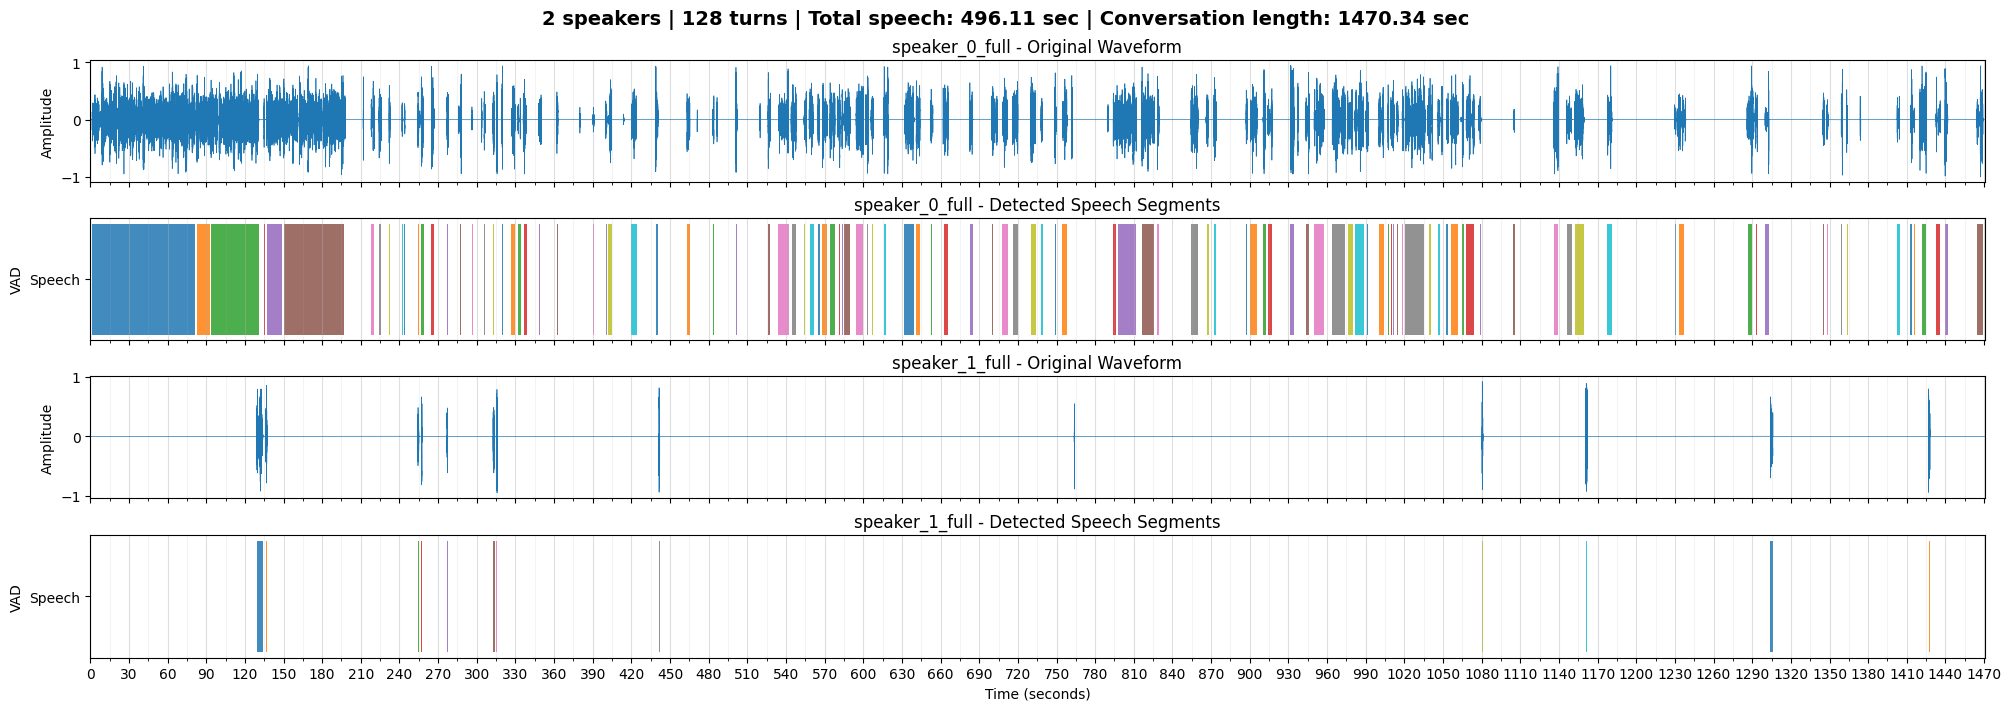

{'speaker_0_full': [{'chunk_id': 'turn_0000',
   'chunk_name': 'turn_0000_t23040_speaker_0_full.wav',
   'start_sample': 23040,
   'end_sample': 1305600,
   'duration_samples': 1282560,
   'start_sec': 1.44,
   'end_sec': 81.6,
   'duration_sec': 80.16,
   'transcript': "years of experience around. I had a bachelor's degree in computer science and also a machine learning degree in data science working as a machine learning. I started my career as a machine engineer in the beginning of 2020. So far that I worked as a software engineer for three years, mainly working with front-end, I was tech basically engineer, working with front-end stack like React, Angular and also Vue and back end using Python sometimes, but also JavaScript mainly. And I decided to make this current change in the beginning of 2020. I started working mainly as a data scientist in the field of NLP, basically creating solutions for Fidelity Post in Brazil. Basically they are migrating the entire platform to the new pl

In [ ]:
plot_all_speakers_turns(
    "output_turns/sample5",
    "diarization_output/sample5",
    save_path=None,
    show=True,
)

In [13]:
import json

# Input and output file paths
input_file = "output_turns/sample5/combined_metadata.json"
output_file = "output_turns/sample5/filtered_metadata.json"

# Read the JSON file (expected to be a list of dictionaries)
with open(input_file, "r", encoding="utf-8") as f:
    data = json.load(f)

# Keep only the 'transcript' and 'speaker' keys from each dictionary
filtered_data = [
    {
        "transcript": item.get("transcript"),
        "speaker": item.get("speaker")
    }
    for item in data
]

# Save the filtered list back to a JSON file
with open(output_file, "w", encoding="utf-8") as f:
    json.dump(filtered_data, f, ensure_ascii=False, indent=2)